# Bài tập về nhà Buổi 1:Module 1- Toán học trong AI 

- **Học viên:** Trần Thị Kiều My
- **Môn học:** Python & Machine Learning 

## Bài 1: Biểu diễn dữ liệu thành ma trận & độ tương đồng 

Mục tiêu: Đưa dữ liệu văn bản về dạng vector và đo độ tương đồng giữa các câu

In [14]:
import numpy as np

cau = [
    "Machine learning uses data.",
    "IoT sensors collect data.",
    "Deep learning needs AI.",
    "Neural networks help ML.",
    "Our MLIoT lab makes AI.",
    "Data improves AI models.",
    "IoT connects smart tools.",
    "ML analyzes sensor data."
]

vocab = sorted({word.replace(".", "").lower() for s in cau for word in s.split()})

def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().replace(".", "").split():
        if w in vocab:
            v[vocab.index(w)] += 1
    return v

X = np.array([to_vector(s) for s in cau])
print(X.shape)
print(X)

(8, 25)
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  1.]
 [0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0.]
 [1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0.
  0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0.
  0.]
 [1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.
  0.]
 [0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.
  0.]]


In [15]:

X_centered = X - X.mean(axis=0)

def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
   
    norm_X = np.linalg.norm(X, axis=1, keepdims=True)
    norm_Y = np.linalg.norm(Y, axis=1, keepdims=True)
    
    norm_X[norm_X == 0] = 1
    norm_Y[norm_Y == 0] = 1
    
    X_normalized = X / norm_X
    Y_normalized = Y / norm_Y
    
    return np.dot(X_normalized, Y_normalized.T)

sim_matrix = cosine_similarity(X)
print("Ma trận tương đồng:\n", np.round(sim_matrix, 2))

Ma trận tương đồng:
 [[1.   0.25 0.25 0.   0.   0.25 0.   0.25]
 [0.25 1.   0.   0.   0.   0.25 0.25 0.25]
 [0.25 0.   1.   0.   0.22 0.25 0.   0.  ]
 [0.   0.   0.   1.   0.   0.   0.   0.25]
 [0.   0.   0.22 0.   1.   0.22 0.   0.  ]
 [0.25 0.25 0.25 0.   0.22 1.   0.   0.25]
 [0.   0.25 0.   0.   0.   0.   1.   0.  ]
 [0.25 0.25 0.   0.25 0.   0.25 0.   1.  ]]


**Nhận xét:**
Ma trận tương đồng (Cosine Similarity) đã thể hiện mối quan hệ ngữ nghĩa giữa các câu. 
- Các giá trị `1.` trên đường chéo chính cho thấy mỗi câu có độ tương đồng tuyệt đối với chính nó.
- Các giá trị khác phản ánh mức độ chia sẻ từ vựng giữa các câu, giúp xác định các câu có nội dung liên quan trong tập dữ liệu

In [16]:
def search_engine(query, data, X):
    query_vec = np.array([to_vector(query)])
    
    scores = cosine_similarity(query_vec, X)
    
    best_idx = np.argmax(scores)
    
    print(f"Từ khóa tìm kiếm: '{query}'")
    print(f"Kết quả phù hợp nhất: '{data[best_idx]}' (Điểm: {scores[0][best_idx]:.2f})")

search_engine("AI", cau, X)
search_engine("IoT", cau, X)

Từ khóa tìm kiếm: 'AI'
Kết quả phù hợp nhất: 'Deep learning needs AI.' (Điểm: 0.50)
Từ khóa tìm kiếm: 'IoT'
Kết quả phù hợp nhất: 'IoT sensors collect data.' (Điểm: 0.50)


**Nhận xét:**
Hệ thống tìm kiếm dựa trên thuật toán 1-NN với Cosine Similarity. Khi nhận truy vấn, hệ thống chuyển đổi nó thành vector cùng chiều và tìm người gần nhất trong tập dữ liệu. Cách tiếp cận này minh chứng hiệu quả của việc ứng dụng đại số tuyến tính trong truy xuất thông tin, tuy nhiên sẽ cần tối ưu hóa hiệu năng khi quy mô dữ liệu tăng lên.

## Bài 2: Biến đổi tuyến tính & SVD 

Mục tiêu: Sử dụng phân rã SVD để giảm chiều dữ liệu và trực quan hóa các câu 

In [17]:

U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
coords = U[:, :2] * S[:2] 

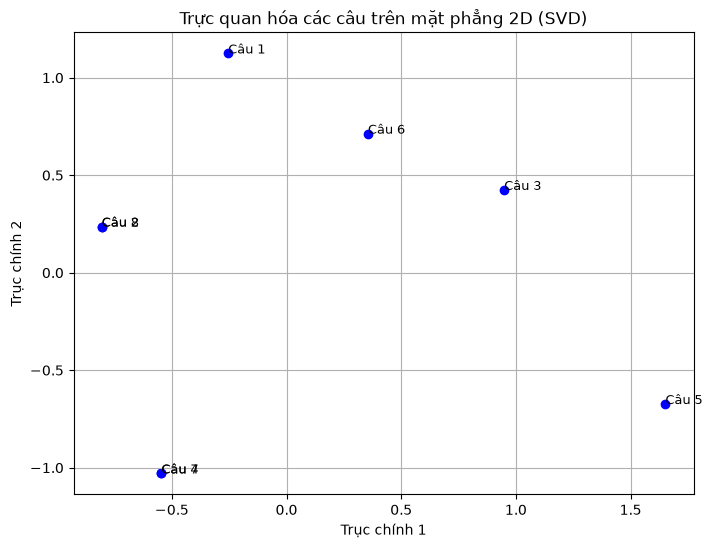

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], color='blue')

for i, txt in enumerate(cau):
    plt.annotate(f"Câu {i+1}", (coords[i, 0], coords[i, 1]), fontsize=9)

plt.title("Trực quan hóa các câu trên mặt phẳng 2D (SVD)")
plt.xlabel("Trục chính 1")
plt.ylabel("Trục chính 2")
plt.grid(True)
plt.show()

**Nhận xét:**
- **Giảm chiều dữ liệu:** Việc áp dụng SVD cho phép đưa ma trận từ 25 chiều (số từ) về không gian 2D, giúp trực quan hóa mối quan hệ giữa các câu
- **Trực quan hóa:** Các câu có chủ đề gần gũi (ví dụ các câu về AI/IoT) có xu hướng nằm gần nhau trên đồ thị, chứng tỏ SVD đã lọc được các đặc trưng ngữ nghĩa gần giống nhau của văn bản

In [19]:
def classify_1NN(query, data, X):
    query_vec = np.array([to_vector(query)])
    
    scores = cosine_similarity(query_vec, X) 
   
    best_idx = np.argmax(scores)
    
    return best_idx, scores[0, best_idx]

query = "Learning data"
idx, score = classify_1NN(query, cau, X)

print(f"Từ khóa tìm kiếm: '{query}'")
print(f"Được phân loại giống câu: '{cau[idx]}'")
print(f"Với độ tương đồng: {score:.2f}")

Từ khóa tìm kiếm: 'Learning data'
Được phân loại giống câu: 'Machine learning uses data.'
Với độ tương đồng: 0.71


**Nhận xét:**

- Em đã cài đặt bộ phân loại 1-NN dựa trên độ tương đồng Cosine.

- Thuật toán hoạt động bằng cách tìm kiếm "người gần nhất" trong không gian vector – câu trong tập dữ liệu có hướng vector gần nhất với vector của từ khóa tìm kiếm.

- Phương pháp này hoạt động hiệu quả trong việc phân loại văn bản dựa trên sự tương đồng về từ, giúp minh họa rõ cách thức các hệ thống gợi ý hoặc phân loại thông tin hoạt động dựa trên đại số tuyến tính.